In [21]:
import pandas as pd
from destinations import extract_places


places, dup_places, places_id, dup_places_id = extract_places("Timeline_15_03_26.json")



df_places = pd.DataFrame(places)
df_dup_places = pd.DataFrame(dup_places)
df_places_id = pd.DataFrame(places_id)
df_dup_places_id = pd.DataFrame(dup_places_id)

print(df_places.head())
print(df_dup_places.head())
print(df_dup_places_id.head())

         lat        lng  year
0  12.999994  77.550504  2016
1  13.000327  77.549709  2016
2  12.978407  77.579539  2016
3   8.482778  76.943591  2016
4  12.902936  77.521434  2016
         lat        lng  year
0  12.999994  77.550504  2016
1  13.000327  77.549709  2016
2  12.978407  77.579539  2016
3   8.482778  76.943591  2016
4  12.902936  77.521434  2016
                      place_id  year
0  ChIJAZBMy5o9rjsRs7xReWDFbGk  2016
1  ChIJecUIuJo9rjsRCPx6gSQcYWM  2016
2  ChIJe628BBIWrjsRm6xlH0hs-xw  2016
3  ChIJNR3otwm7BTsR9x46IbftLx0  2016
4  ChIJlcRpoqY_rjsRaYM90tLmIkw  2016


In [22]:
print("unique places:")
print(df_places.count())

print("duplicate places:")
print(df_dup_places.count())

unique places:
lat     15607
lng     15607
year    15607
dtype: int64
duplicate places:
lat     15607
lng     15607
year    15607
dtype: int64


In [23]:
print(df_dup_places.groupby(['lat', 'lng']).size().reset_index(name='counts').sort_values(by='counts', ascending=False).head(10))

            lat        lng  counts
876   12.932170  77.522945    1018
2120  52.461768  13.517560     852
817   12.929816  77.520746     589
2795  52.543159  13.412808     501
816   12.929809  77.520738     490
2012  52.451751  13.380756     481
2029  52.455127  13.509395     467
675   12.928054  77.522417     395
1550  13.129463  77.587659     366
724   12.928221  77.522018     293


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, 'ChIJUcGXEnA_rjsRMrSox30tbw4'),
  Text(1, 0, 'ChIJG1Yzz1A-rjsRAAAAAAAAAAA'),
  Text(2, 0, 'ChIJw0eB0blIqEcRKQ2bh2KN8I8'),
  Text(3, 0, 'ChIJ2bTOy1A-rjsRAAAAAAAAAAA'),
  Text(4, 0, 'ChIJQWh5QVc-rjsRAAAAAAAAAAA'),
  Text(5, 0, 'ChIJlfQ54lk-rjsRp71A7OxmysY'),
  Text(6, 0, 'ChIJT3iQ4Vk-rjsR46F7dYHZu2w'),
  Text(7, 0, 'ChIJA79Q1a9IqEcRPDZBFUCgcrU'),
  Text(8, 0, 'ChIJ51e-Y1FFqEcRtoJtLan9_CY'),
  Text(9, 0, 'ChIJHRQvzwFSqEcR67NNEkdTjtM')])

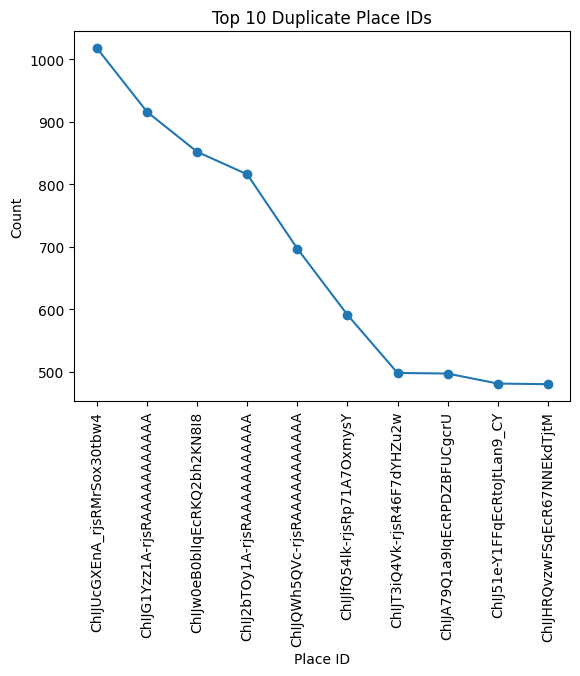

In [24]:
import matplotlib.pyplot as plt

df_dup_places_id_plot = df_dup_places_id.groupby(['place_id']).size().reset_index(name='counts').sort_values(by='counts', ascending=False).head(10)

plt.plot(df_dup_places_id_plot['place_id'], df_dup_places_id_plot['counts'], marker='o')
plt.title('Top 10 Duplicate Place IDs')
plt.xlabel('Place ID')
plt.ylabel('Count')
plt.xticks(rotation=90)

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
 [Text(0, 0, '2016'),
  Text(1, 0, '2017'),
  Text(2, 0, '2018'),
  Text(3, 0, '2019'),
  Text(4, 0, '2020'),
  Text(5, 0, '2021'),
  Text(6, 0, '2022'),
  Text(7, 0, '2023'),
  Text(8, 0, '2024'),
  Text(9, 0, '2025'),
  Text(10, 0, '2026')])

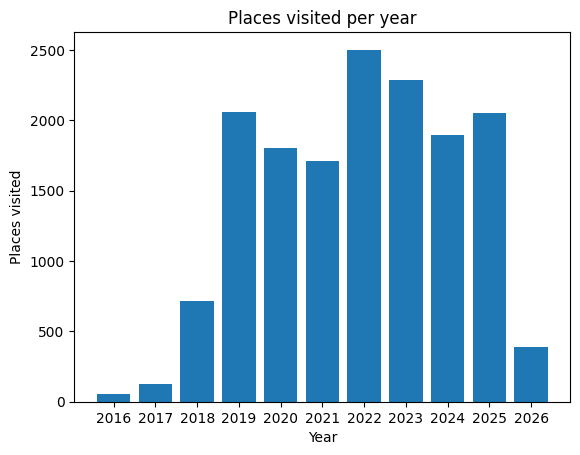

In [25]:
df_dup_places_id_plot = df_dup_places_id.groupby(['year']).size().reset_index(name='counts').sort_values(by='year', ascending=True)

plt.bar(df_dup_places_id_plot['year'], df_dup_places_id_plot['counts'])
plt.title('Places visited per year')
plt.xlabel('Year')
plt.ylabel('Places visited')
plt.xticks(rotation=0)

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
 [Text(0, 0, '2016'),
  Text(1, 0, '2017'),
  Text(2, 0, '2018'),
  Text(3, 0, '2019'),
  Text(4, 0, '2020'),
  Text(5, 0, '2021'),
  Text(6, 0, '2022'),
  Text(7, 0, '2023'),
  Text(8, 0, '2024'),
  Text(9, 0, '2025'),
  Text(10, 0, '2026')])

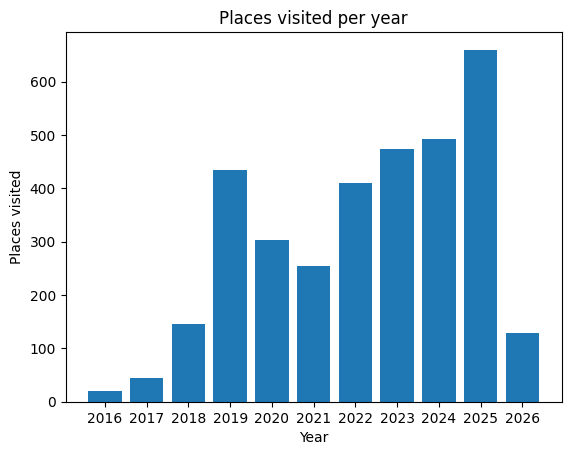

In [29]:
df_places_id_plot = df_places_id.groupby(['year'])["place_id"].nunique().reset_index(name='counts').sort_values(by='year', ascending=True)

plt.bar(df_places_id_plot['year'], df_places_id_plot['counts'])
plt.title('Places visited per year')
plt.xlabel('Year')
plt.ylabel('Places visited')
plt.xticks(rotation=0)